In [2]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
(_,_), (images, labels) = mnist.load_data()

In [ ]:
def order_by_number(dataset_images, dataset_labels):
    ordered_images = {0: [], 1: [], 2:[], 3:[], 4:[], 5:[], 6:[], 7:[], 8:[], 9:[]}
    for i, _ in enumerate(dataset_images):
        ordered_images[dataset_labels[i]].append(dataset_images[i])
    return ordered_images

ordered_images = order_by_number(images, labels)


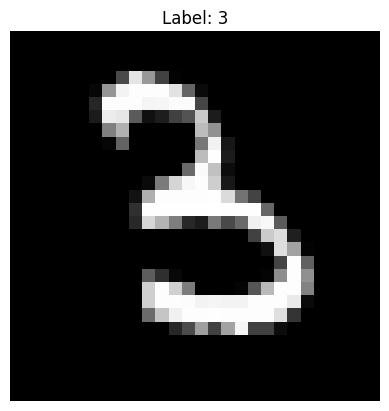

In [ ]:
index = np.random.randint(0, images.shape[0])
image = images[index]
label = labels[index]

# Display it
plt.imshow(image, cmap='gray')
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [ ]:
def print_with_center(start, end):
    # Plot the image
    fig, ax = plt.subplots()
    ax.imshow(image, cmap='gray')

    # Highlight the center square
    rect = Rectangle((start, start), 8, 8, edgecolor='red', facecolor='none', linewidth=2)
    ax.add_patch(rect)

    plt.show()

def check_center(image):
    center_size = 8

    start = (image.shape[0] - center_size) // 2
    end = start + center_size

    center_square = image[start:end, start:end]
                           
    score = center_square.mean() / 255.0

    print_with_center(start, end)

    return score

def vertical_symmetry(image):
    flipped = np.fliplr(image)
    diff = np.abs(image - flipped)
    score = 1 - (diff.mean() / 255.0)
    return score

def horizontal_symmetry(image):
    flipped = np.flipud(image)
    diff = np.abs(image - flipped)
    score = 1 - (diff.mean() / 255.0)
    return score

def top_bottom_balance(image):
    mid = image.shape[0] // 2
    top = image[:mid, :].mean()
    bottom = image[mid:, :].mean()
    
    return (top - bottom) / 255.0

features = [
    check_center(image),
    vertical_symmetry(image),
    horizontal_symmetry(image),
    top_bottom_balance(image),
]

print(features)

def classify(features):
    center, v_sym, h_sym, tb_balance = features

    # 8: heel symmetrisch en veel in het midden
    if v_sym > 0.8 and h_sym > 0.8 and center > 0.5:
        return 8

    # 0: symmetrisch maar leeg midden
    if v_sym > 0.7 and center < 0.4:
        return 0

    # 1: weinig symmetrie en weinig center
    if v_sym < 0.4 and center < 0.3:
        return 1

    # 9: boven zwaarder
    if tb_balance > 0.1:
        return 9

    # 6: onder zwaarder
    if tb_balance < -0.1:
        return 6

    # 3: weinig verticale symmetrie, beetje horizontaal
    if v_sym < 0.5 and h_sym > 0.4:
        return 3

    # 7: weinig symmetrie en boven zwaar
    if v_sym < 0.5 and tb_balance > 0:
        return 7

    # 4: fallback voor aparte vorm
    return 4

prediction = classify(features)
print("Voorspeld cijfer:", prediction)


NameError: name 'image' is not defined

In [ ]:
check_avg_pixels(image)